# Random Forest Classifier — Breast Cancer Dataset

**Goal:** Predict whether a tumor is **Malignant (M)** or **Benign (B)** using 30 numerical features.

**Steps:**
1. Load & explore data
2. Preprocess
3. Train Random Forest
4. Evaluate the model

## Step 1 — Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## Step 2 — Load & Explore Data

In [56]:
df = pd.read_csv('breast-cancer.csv')

print("Shape:", df.shape)
print("\nClass distribution:\n", df['diagnosis'].value_counts())
df.head()

Shape: (569, 32)

Class distribution:
 diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 3 — Preprocess Data

- Drop the `id` column (not a feature)
- Encode `diagnosis`: M → 1, B → 0
- Split into train / test sets

In [57]:
df.drop(columns=['id'], inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 455
Test size : 114


## Step 4 — Train Random Forest

- `n_estimators=100` → 100 decision trees in the forest
- Each tree votes; majority class wins

In [58]:
rf = RandomForestClassifier( n_estimators= 50, min_samples_split= 5, min_samples_leaf= 1, max_features= 'log2', max_depth= 5, criterion= 'entropy')

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


## Step 5 — Evaluate the Model

### Confusion Matrix
Shows correct vs incorrect predictions for each class.

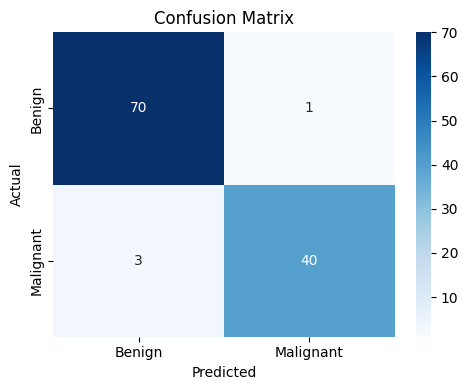


Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

### Feature Importance
Which features matter most for the prediction?

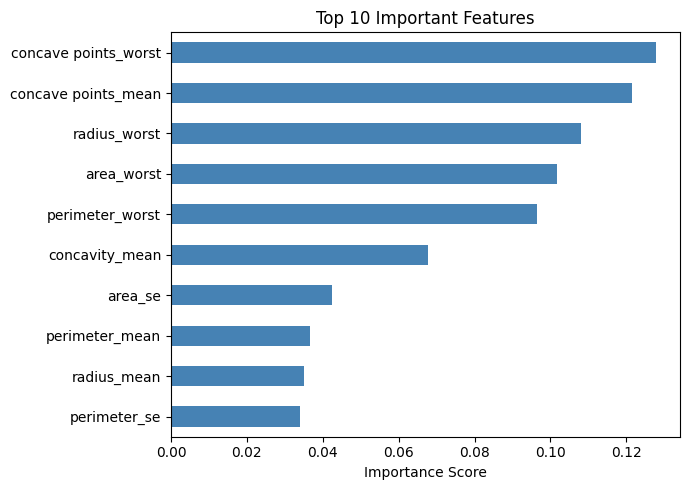

In [60]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

plt.figure(figsize=(7, 5))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 6 — Hyperparameter Tuning

We use **RandomizedSearchCV** to find the best combination of hyperparameters.  
It tries random combinations (faster than GridSearchCV) with 5-fold cross-validation.

| Parameter | What it controls |
|-----------|-----------------|
| `n_estimators` | Number of trees |
| `max_depth` | How deep each tree can grow |
| `min_samples_split` | Min samples needed to split a node |
| `min_samples_leaf` | Min samples at a leaf node |
| `max_features` | Features considered at each split |

In [61]:
param_grid = {
    'n_estimators'    : [50, 100, 200, 300],
    'max_depth'       : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'    : ['sqrt', 'log2'],
    'criterion': ['gini','entropy']
}

rf_base = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = param_grid,
    n_iter      = 20,          # try 20 random combos
    cv          = 5,           # 5-fold cross-validation
    scoring     = 'accuracy',
    random_state= 42,
    n_jobs      = -1           # use all CPU cores
)

random_search.fit(X_train, y_train)

print("Best Parameters:\n", random_search.best_params_)
print("\nBest CV Accuracy:", round(random_search.best_score_, 4))

Best Parameters:
 {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'criterion': 'entropy'}

Best CV Accuracy: 0.9648


## Step 7 — Evaluate Tuned Model

Compare the **baseline** model vs the **tuned** model on the test set.

In [62]:
best_rf = random_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("Baseline Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Tuned    Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))

print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Benign', 'Malignant']))

Baseline Accuracy : 0.9649
Tuned    Accuracy : 0.9649

Classification Report (Tuned Model):

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



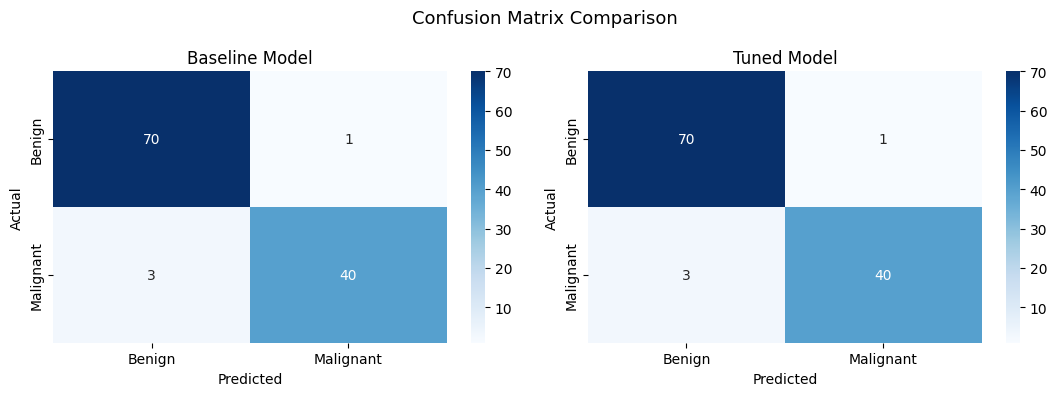

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in zip(axes,
                             [y_pred, y_pred_tuned],
                             ['Baseline Model', 'Tuned Model']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=13)
plt.tight_layout()
plt.show()